# Task 1 - Trained SVM based on gathered data from CARLA Frames

This notebook implements following pipeline:

- use CARLA/science-truck extracted camera frames,
- detect the green route line with OpenCV,
- generate centerline features,
- create automatic labels from line geometry,
- visual check the labels,
- train and tune an SVM with scikit-learn,
- evaluate the trained classifier.

## 1. Imports and Configuration

In [40]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT = Path.cwd()
FRAME_ROOT = ROOT / "extracted_frames"

CLASS_NAMES = np.array(["LEFT", "STRAIGHT", "RIGHT"])
TARGET_BY_LABEL = {"LEFT": -1, "STRAIGHT": 0, "RIGHT": 1}
LABEL_BY_TARGET = {-1: "LEFT", 0: "STRAIGHT", 1: "RIGHT"}

# Use stride to limit near-duplicate consecutive frames.
FRAME_STRIDE = 10
SMALL_SESSION_LIMIT = 200
MAX_FRAMES_PER_SESSION = 2000

# Green line detection parameters.
HSV_LOWER = np.array([40, 40, 40], dtype=np.uint8)
HSV_UPPER = np.array([90, 255, 255], dtype=np.uint8)
KERNEL_SIZE = (7, 7)
ROI_START_FRACTION = 0.40
MIN_GREEN_PIXELS = 150
MIN_PIXELS_PER_BAND = 12

# Label threshold in normalized image-width units.
DIRECTION_DEADBAND = 0.025

## 2. Discover Extracted CARLA Frames

In [27]:
def collect_frame_paths(frame_root=FRAME_ROOT):
    if not frame_root.exists():
        raise FileNotFoundError(f"Frame root not found: {frame_root}")

    rows = []
    for session_dir in sorted(p for p in frame_root.iterdir() if p.is_dir()):
        files = sorted(
            list(session_dir.glob("*.jpg"))
            + list(session_dir.glob("*.jpeg"))
            + list(session_dir.glob("*.png"))
        )

        if len(files) <= SMALL_SESSION_LIMIT:
            selected = files
        else:
            selected = files[::FRAME_STRIDE]

        if MAX_FRAMES_PER_SESSION is not None:
            selected = selected[:MAX_FRAMES_PER_SESSION]

        for path in selected:
            rows.append({
                "session": session_dir.name,
                "frame_path": path,
                "frame_name": path.name,
            })

    return pd.DataFrame(rows)

frames_df = collect_frame_paths()

print("Sessions:", frames_df["session"].nunique())
print("Selected frames:", len(frames_df))
display(frames_df.groupby("session").size().rename("selected_frames").to_frame())
display(frames_df.head())

Sessions: 3
Selected frames: 3579


,selected_frames
session,
session_2026-05-18_11-31-16,2000
session_2026-05-18_11-48-05,1564
session_2026-05-18_11-53-36,15


,session,frame_path,frame_name
0,session_2026-05-18_11-31-16,/Users/dariashushkova/Downloads/studies/autono...,frame_000001.jpg
1,session_2026-05-18_11-31-16,/Users/dariashushkova/Downloads/studies/autono...,frame_000011.jpg
2,session_2026-05-18_11-31-16,/Users/dariashushkova/Downloads/studies/autono...,frame_000021.jpg
3,session_2026-05-18_11-31-16,/Users/dariashushkova/Downloads/studies/autono...,frame_000031.jpg
4,session_2026-05-18_11-31-16,/Users/dariashushkova/Downloads/studies/autono...,frame_000041.jpg


## 3. Inspect a Raw Frame

Sample frame: extracted_frames/session_2026-05-18_11-31-16/frame_000001.jpg
Shape: (720, 1280, 3)
dtype: uint8


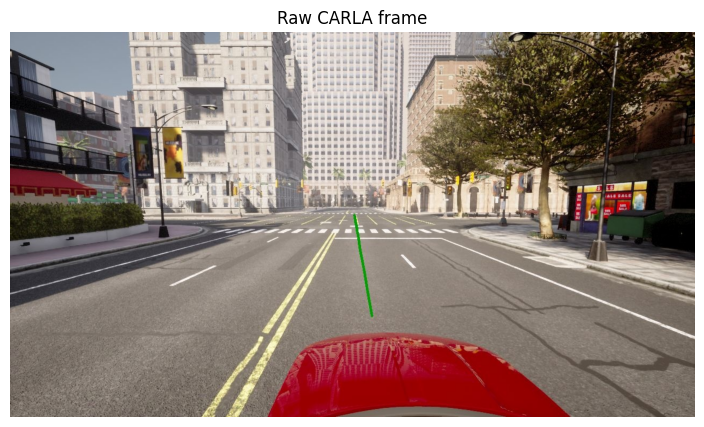

In [28]:
sample_path = frames_df.iloc[0]["frame_path"]
sample_image = cv2.imread(str(sample_path))

if sample_image is None:
    raise ValueError(f"Could not load sample image: {sample_path}")

print("Sample frame:", sample_path.relative_to(ROOT))
print("Shape:", sample_image.shape)
print("dtype:", sample_image.dtype)

plt.figure(figsize=(12, 5))
plt.imshow(cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB))
plt.title("Raw CARLA frame")
plt.axis("off")
plt.show()

## 4. OpenCV Green Mask and Centerline Extraction

In [29]:
def create_green_mask(image_bgr):
    """Return a denoised binary mask for the green route line in the lower ROI."""
    h, _ = image_bgr.shape[:2]
    roi_start = int(h * ROI_START_FRACTION)
    roi = image_bgr[roi_start:, :]

    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, HSV_LOWER, HSV_UPPER)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, KERNEL_SIZE)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    return mask, roi_start


def center_x_in_band(mask, y0, y1):
    """Return the mean x-position of green pixels in one horizontal band."""
    band = mask[y0:y1, :]
    ys, xs = np.nonzero(band)

    if len(xs) < MIN_PIXELS_PER_BAND:
        return np.nan, int(len(xs))

    return float(xs.mean()), int(len(xs))


def extract_centerline_features(image_bgr):
    """
    Extract interpretable line-following features from the green mask.

    The key label feature is direction_score:
        direction_score > 0 means the detected centerline moves right ahead,
        direction_score < 0 means it moves left ahead.
    """
    h, w = image_bgr.shape[:2]
    mask, roi_start = create_green_mask(image_bgr)
    green_pixels = int(np.count_nonzero(mask))

    if green_pixels < MIN_GREEN_PIXELS:
        return None, mask, roi_start

    roi_h = mask.shape[0]
    bands = {
        "near": (int(0.70 * roi_h), roi_h),
        "middle": (int(0.45 * roi_h), int(0.70 * roi_h)),
        "far": (0, int(0.45 * roi_h)),
    }

    centers = {}
    counts = {}
    for name, (y0, y1) in bands.items():
        centers[name], counts[name] = center_x_in_band(mask, y0, y1)

    valid_centers = [x for x in centers.values() if not np.isnan(x)]
    if len(valid_centers) < 2:
        return None, mask, roi_start

    # Fill missing band centers with the available centerline mean so the feature
    # vector remains numeric while still keeping per-band pixel counts.
    fallback_x = float(np.mean(valid_centers))
    near_x = centers["near"] if not np.isnan(centers["near"]) else fallback_x
    middle_x = centers["middle"] if not np.isnan(centers["middle"]) else fallback_x
    far_x = centers["far"] if not np.isnan(centers["far"]) else fallback_x

    near_offset = (near_x - w / 2.0) / (w / 2.0)
    middle_offset = (middle_x - w / 2.0) / (w / 2.0)
    far_offset = (far_x - w / 2.0) / (w / 2.0)

    direction_score = (far_x - near_x) / w
    curvature_proxy = (middle_x - 0.5 * (near_x + far_x)) / (w / 2.0)

    left_pixels = int(np.count_nonzero(mask[:, : w // 2]))
    right_pixels = int(np.count_nonzero(mask[:, w // 2 :]))
    left_right_balance = (right_pixels - left_pixels) / max(1, right_pixels + left_pixels)

    ys, xs = np.nonzero(mask)
    bbox_width = float(xs.max() - xs.min() + 1) if len(xs) else 0.0
    bbox_height = float(ys.max() - ys.min() + 1) if len(ys) else 0.0

    features = {
        "near_x": near_x,
        "middle_x": middle_x,
        "far_x": far_x,
        "near_offset": near_offset,
        "middle_offset": middle_offset,
        "far_offset": far_offset,
        "direction_score": direction_score,
        "curvature_proxy": curvature_proxy,
        "green_pixel_ratio": green_pixels / mask.size,
        "left_right_balance": left_right_balance,
        "bbox_width_norm": bbox_width / w,
        "bbox_height_norm": bbox_height / roi_h,
        "near_pixels": counts["near"],
        "middle_pixels": counts["middle"],
        "far_pixels": counts["far"],
        "roi_start": roi_start,
    }

    return features, mask, roi_start


def label_from_features(features, deadband=DIRECTION_DEADBAND):
    score = features["direction_score"]

    if score < -deadband:
        return "LEFT", -1
    if score > deadband:
        return "RIGHT", 1
    return "STRAIGHT", 0

## 5. Visualize Mask, Centerline, and Automatic Label

Automatic label: RIGHT target: 1


,value
near_x,748.106558
middle_x,671.861827
far_x,824.351289
near_offset,0.168916
middle_offset,0.049784
far_offset,0.288049
direction_score,0.059566
curvature_proxy,-0.178699
green_pixel_ratio,0.008628
left_right_balance,0.643261


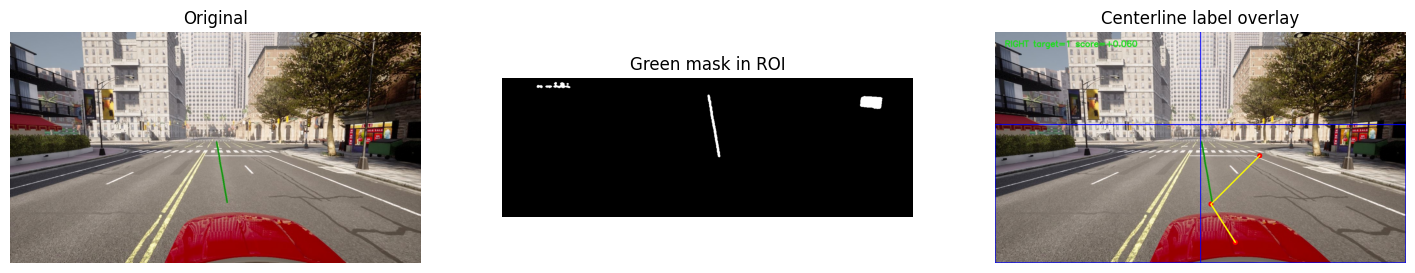

In [30]:
def draw_centerline_overlay(image_bgr, mask, features):
    overlay = image_bgr.copy()
    h, w = image_bgr.shape[:2]
    roi_start = int(features["roi_start"])

    cv2.rectangle(overlay, (0, roi_start), (w - 1, h - 1), (255, 0, 0), 2)
    cv2.line(overlay, (w // 2, 0), (w // 2, h - 1), (255, 0, 0), 2)

    points = [
        (features["near_x"], int(roi_start + 0.85 * (h - roi_start))),
        (features["middle_x"], int(roi_start + 0.575 * (h - roi_start))),
        (features["far_x"], int(roi_start + 0.225 * (h - roi_start))),
    ]
    points = [(int(round(x)), int(round(y))) for x, y in points]

    for point in points:
        cv2.circle(overlay, point, 8, (0, 0, 255), -1)

    cv2.line(overlay, points[0], points[1], (0, 255, 255), 3)
    cv2.line(overlay, points[1], points[2], (0, 255, 255), 3)

    label, target = label_from_features(features)
    text = f"{label} target={target} score={features['direction_score']:+.3f}"
    cv2.putText(overlay, text, (30, 45), cv2.FONT_HERSHEY_SIMPLEX, 0.85, (30, 220, 30), 2, cv2.LINE_AA)

    return overlay


features, mask, roi_start = extract_centerline_features(sample_image)

if features is None:
    print("No valid green line found in sample frame.")
else:
    label, target = label_from_features(features)
    print("Automatic label:", label, "target:", target)
    display(pd.DataFrame([features]).T.rename(columns={0: "value"}))

    overlay = draw_centerline_overlay(sample_image, mask, features)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].imshow(cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original")
    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Green mask in ROI")
    axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[2].set_title("Centerline label overlay")
    for ax in axes:
        ax.axis("off")
    plt.show()

## 6. Build the CARLA Feature Dataset

In [31]:
def build_feature_dataset(frames):
    rows = []
    skipped = []

    for _, row in frames.iterrows():
        path = row["frame_path"]
        image = cv2.imread(str(path))

        if image is None:
            skipped.append({"frame_path": path, "reason": "read_error"})
            continue

        features, mask, roi_start = extract_centerline_features(image)
        if features is None:
            skipped.append({"frame_path": path, "reason": "no_green_line"})
            continue

        label, target = label_from_features(features)
        sample = {
            "session": row["session"],
            "frame_name": row["frame_name"],
            "frame_path": str(path.relative_to(ROOT)),
            "label": label,
            "target": target,
        }
        sample.update(features)
        rows.append(sample)

    return pd.DataFrame(rows), pd.DataFrame(skipped)

labelled_df, skipped_df = build_feature_dataset(frames_df)

print("Input frames:", len(frames_df))
print("Labelled frames:", len(labelled_df))
print("Skipped frames:", len(skipped_df))

if len(labelled_df) == 0:
    raise RuntimeError("No labelled frames were generated. Check green mask parameters.")

display(labelled_df.head())
display(labelled_df["label"].value_counts().reindex(CLASS_NAMES, fill_value=0).rename("count").to_frame())
display(labelled_df.groupby(["session", "label"]).size().unstack(fill_value=0))

Input frames: 3579
Labelled frames: 3133
Skipped frames: 446


,session,frame_name,frame_path,label,target,near_x,middle_x,far_x,near_offset,middle_offset,...,direction_score,curvature_proxy,green_pixel_ratio,left_right_balance,bbox_width_norm,bbox_height_norm,near_pixels,middle_pixels,far_pixels,roi_start
0,session_2026-05-18_11-31-16,frame_000001.jpg,extracted_frames/session_2026-05-18_11-31-16/f...,RIGHT,1,748.106558,671.861827,824.351289,0.168916,0.049784,...,0.059566,-0.178699,0.008628,0.643261,0.841406,0.543981,0,427,4344,288
1,session_2026-05-18_11-31-16,frame_000011.jpg,extracted_frames/session_2026-05-18_11-31-16/f...,RIGHT,1,746.450422,671.878505,821.022340,0.166329,0.049810,...,0.058259,-0.174778,0.008626,0.635220,0.840625,0.541667,0,428,4342,288
2,session_2026-05-18_11-31-16,frame_000021.jpg,extracted_frames/session_2026-05-18_11-31-16/f...,RIGHT,1,752.203057,671.783217,832.622897,0.175317,0.049661,...,0.062828,-0.188484,0.008516,0.664048,0.840625,0.541667,0,429,4280,288
3,session_2026-05-18_11-31-16,frame_000031.jpg,extracted_frames/session_2026-05-18_11-31-16/f...,RIGHT,1,747.637449,671.787879,823.487019,0.168184,0.049669,...,0.059257,-0.177772,0.008577,0.643685,0.840625,0.543981,0,429,4314,288
4,session_2026-05-18_11-31-16,frame_000041.jpg,extracted_frames/session_2026-05-18_11-31-16/f...,RIGHT,1,749.385371,671.874126,826.896616,0.170915,0.049803,...,0.060556,-0.181667,0.008577,0.650011,0.840625,0.543981,0,429,4314,288


,count
label,
LEFT,737
STRAIGHT,1357
RIGHT,1039


label,LEFT,RIGHT,STRAIGHT
session,,,
session_2026-05-18_11-31-16,484,494,861
session_2026-05-18_11-48-05,253,545,481
session_2026-05-18_11-53-36,0,0,15


## 7. Visual Sanity Check of Automatic Labels

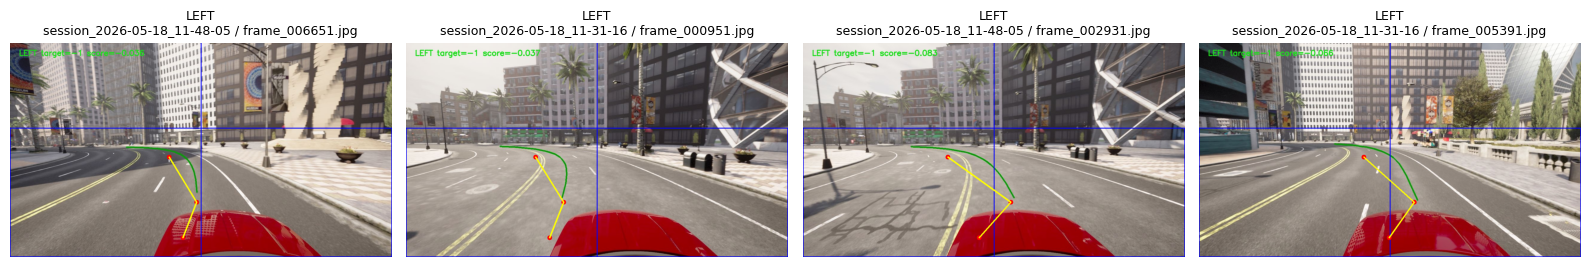

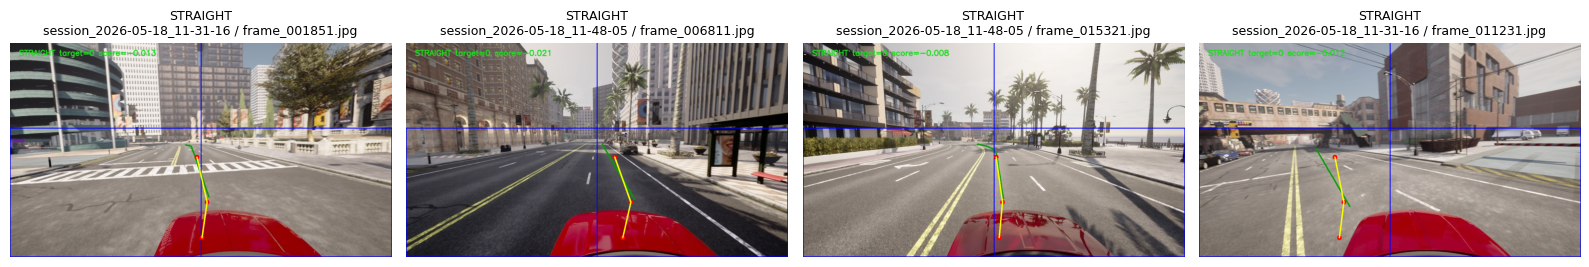

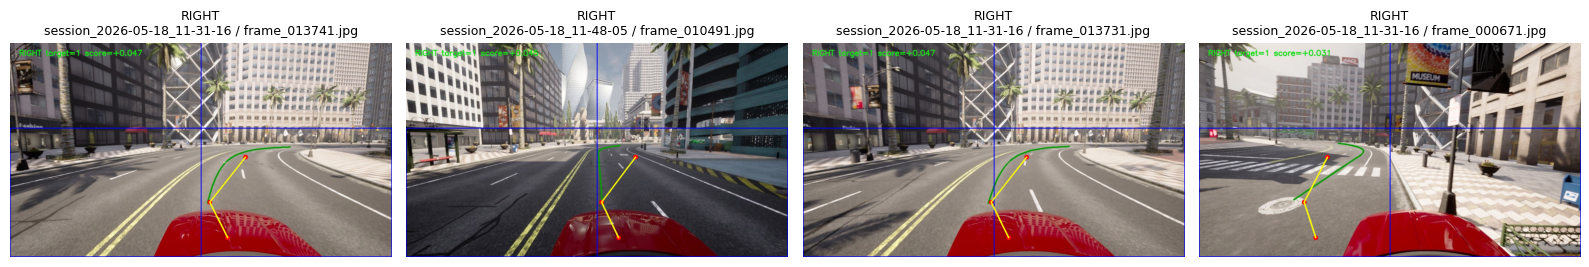

In [32]:
def show_label_examples(labelled, max_per_class=4):
    for label in CLASS_NAMES:
        examples = labelled[labelled["label"] == label]
        if examples.empty:
            print(f"No examples for {label}")
            continue

        examples = examples.sample(
            n=min(max_per_class, len(examples)),
            random_state=RANDOM_STATE,
        )

        fig, axes = plt.subplots(1, len(examples), figsize=(4 * len(examples), 3.2))
        if len(examples) == 1:
            axes = [axes]

        for ax, (_, row) in zip(axes, examples.iterrows()):
            image = cv2.imread(str(ROOT / row["frame_path"]))
            features, mask, roi_start = extract_centerline_features(image)
            overlay = draw_centerline_overlay(image, mask, features)
            ax.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
            ax.set_title(f"{label}\n{row['session']} / {row['frame_name']}", fontsize=9)
            ax.axis("off")

        plt.tight_layout()
        plt.show()

show_label_examples(labelled_df, max_per_class=4)

### Sanity-check instruction

Before training is trusted, inspect the examples above:

- `LEFT`: far centerline point should move left relative to the near point.
- `RIGHT`: far centerline point should move right relative to the near point.
- `STRAIGHT`: near, middle, and far centerline points should be approximately aligned.

If too many examples are wrong, adjust `DIRECTION_DEADBAND`, `ROI_START_FRACTION`, or the HSV thresholds, then re-run the dataset cells.

## 8. Feature Matrix for SVM

In [33]:
FEATURE_COLUMNS = [
    "near_offset",
    "middle_offset",
    "far_offset",
    "direction_score",
    "curvature_proxy",
    "green_pixel_ratio",
    "left_right_balance",
    "bbox_width_norm",
    "bbox_height_norm",
    "near_pixels",
    "middle_pixels",
    "far_pixels",
]

X = labelled_df[FEATURE_COLUMNS].astype(float)
y = labelled_df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.describe().T)

X shape: (3133, 12)
y shape: (3133,)


,count,mean,std,min,25%,50%,75%,max
near_offset,3133.0,0.060399,0.182249,-0.942069,-0.026204,0.067062,0.156989,0.905474
middle_offset,3133.0,0.044769,0.170852,-0.997363,-0.024115,0.051273,0.123491,0.916951
far_offset,3133.0,0.073513,0.258452,-0.942635,-0.061411,0.060397,0.221385,0.929347
direction_score,3133.0,0.006557,0.065536,-0.749212,-0.022440,-0.000149,0.042154,0.276756
curvature_proxy,3133.0,-0.022187,0.187885,-0.783675,-0.127069,-0.000116,0.066497,0.905429
green_pixel_ratio,3133.0,0.006201,0.003463,0.001311,0.003516,0.005089,0.008252,0.026270
left_right_balance,3133.0,0.354208,0.705969,-1.000000,-0.181667,0.616982,1.000000,1.000000
bbox_width_norm,3133.0,0.338569,0.231590,0.007031,0.137500,0.317969,0.505469,1.000000
bbox_height_norm,3133.0,0.486368,0.069463,0.206019,0.449074,0.479167,0.537037,1.000000
near_pixels,3133.0,0.177785,4.418048,0.000000,0.000000,0.000000,0.000000,155.000000


## 9. Train and Evaluate a Baseline SVM

Baseline accuracy: 0.9579081632653061
Baseline macro F1: 0.9567844462453828

              precision    recall  f1-score   support

        LEFT       0.96      0.93      0.95       184
    STRAIGHT       0.97      0.94      0.96       340
       RIGHT       0.94      0.99      0.96       260

    accuracy                           0.96       784
   macro avg       0.96      0.96      0.96       784
weighted avg       0.96      0.96      0.96       784



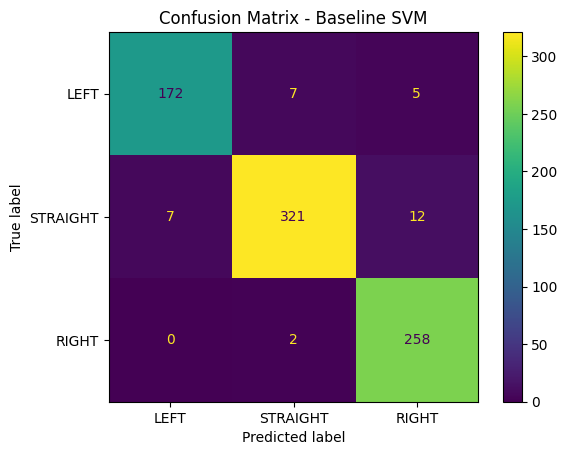

In [34]:
class_counts = y.value_counts()
if len(class_counts) < 2:
    raise RuntimeError("Need at least two classes to train an SVM.")
if class_counts.min() < 2:
    raise RuntimeError("Each class needs at least two samples for stratified train/test split.")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

baseline_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced")),
])

baseline_pipeline.fit(X_train, y_train)
y_pred_baseline = baseline_pipeline.predict(X_test)

print("Baseline accuracy:", accuracy_score(y_test, y_pred_baseline))
print("Baseline macro F1:", f1_score(y_test, y_pred_baseline, average="macro"))
print()
print(classification_report(y_test, y_pred_baseline, labels=CLASS_NAMES, zero_division=0))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_baseline, labels=CLASS_NAMES),
    display_labels=CLASS_NAMES,
).plot(values_format="d")
plt.title("Confusion Matrix - Baseline SVM")
plt.show()

## 10. Kernel and Parameter Optimization

Best parameters: {'svm__C': 10.0, 'svm__kernel': 'linear'}
Best CV macro F1: 0.993094518869258
Final test accuracy: 0.9936224489795918
Final test macro F1: 0.9935629908397852

              precision    recall  f1-score   support

        LEFT       0.98      1.00      0.99       184
    STRAIGHT       0.99      0.99      0.99       340
       RIGHT       1.00      0.99      1.00       260

    accuracy                           0.99       784
   macro avg       0.99      0.99      0.99       784
weighted avg       0.99      0.99      0.99       784



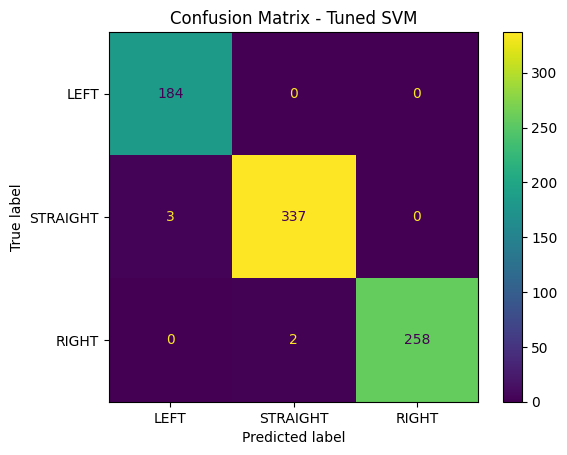

In [35]:
param_grid = [
    {
        "svm__kernel": ["linear"],
        "svm__C": [0.1, 1.0, 10.0],
    },
    {
        "svm__kernel": ["rbf"],
        "svm__C": [0.1, 1.0, 10.0, 50.0],
        "svm__gamma": ["scale", 0.01, 0.1, 1.0],
    },
    {
        "svm__kernel": ["poly"],
        "svm__C": [0.1, 1.0, 10.0],
        "svm__degree": [2, 3],
        "svm__gamma": ["scale"],
    },
]

search_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(class_weight="balanced")),
])

grid = GridSearchCV(
    search_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV macro F1:", grid.best_score_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Final test accuracy:", accuracy_score(y_test, y_pred))
print("Final test macro F1:", f1_score(y_test, y_pred, average="macro"))
print()
print(classification_report(y_test, y_pred, labels=CLASS_NAMES, zero_division=0))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred, labels=CLASS_NAMES),
    display_labels=CLASS_NAMES,
).plot(values_format="d")
plt.title("Confusion Matrix - Tuned SVM")
plt.show()

## 11. Cross-Validation of the Tuned Model

In [36]:
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=3,
    scoring="f1_macro",
)

print("3-fold macro F1 scores:", cv_scores)
print("Mean macro F1:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

3-fold macro F1 scores: [0.9943195  0.99136659 0.99393331]
Mean macro F1: 0.9932064660409151
Standard deviation: 0.0013105091065430063


## 12. Error Analysis: Inspect Misclassified Frames

Misclassified test frames: 5


,session,frame_name,label,prediction,direction_score
2304,session_2026-05-18_11-48-05,frame_004941.jpg,STRAIGHT,LEFT,-0.024998
486,session_2026-05-18_11-31-16,frame_004891.jpg,STRAIGHT,LEFT,-0.024429
1287,session_2026-05-18_11-31-16,frame_013831.jpg,RIGHT,STRAIGHT,0.025521
2881,session_2026-05-18_11-48-05,frame_011851.jpg,STRAIGHT,LEFT,-0.024586
68,session_2026-05-18_11-31-16,frame_000691.jpg,RIGHT,STRAIGHT,0.025391


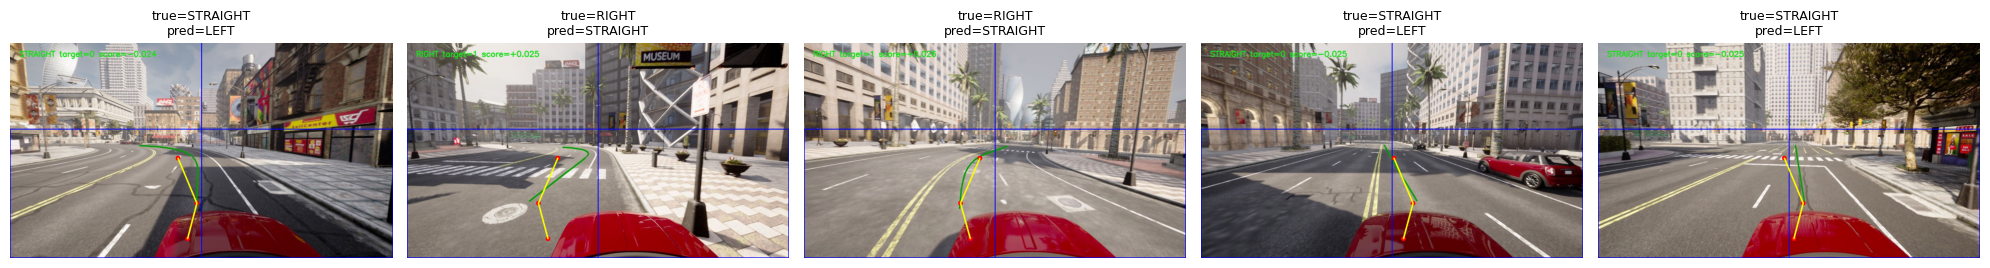

In [37]:
test_meta = labelled_df.loc[X_test.index].copy()
test_meta["prediction"] = y_pred
misclassified = test_meta[test_meta["label"] != test_meta["prediction"]]

print("Misclassified test frames:", len(misclassified))
display(misclassified[["session", "frame_name", "label", "prediction", "direction_score"]].head(20))

n_show = min(8, len(misclassified))
if n_show > 0:
    examples = misclassified.sample(n=n_show, random_state=RANDOM_STATE)
    fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 3.2))
    if n_show == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, examples.iterrows()):
        image = cv2.imread(str(ROOT / row["frame_path"]))
        features, mask, roi_start = extract_centerline_features(image)
        overlay = draw_centerline_overlay(image, mask, features)
        ax.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        ax.set_title(f"true={row['label']}\npred={row['prediction']}", fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No misclassified examples in this split.")

## 13. Robustness Check: Mask Threshold Sensitivity

,deadband,LEFT,STRAIGHT,RIGHT
0,0.005,1433,271,1429
1,0.010,1178,660,1295
2,0.020,843,1182,1108
3,0.025,737,1357,1039
4,0.030,665,1506,962
5,0.040,543,1782,808
6,0.050,451,1991,691


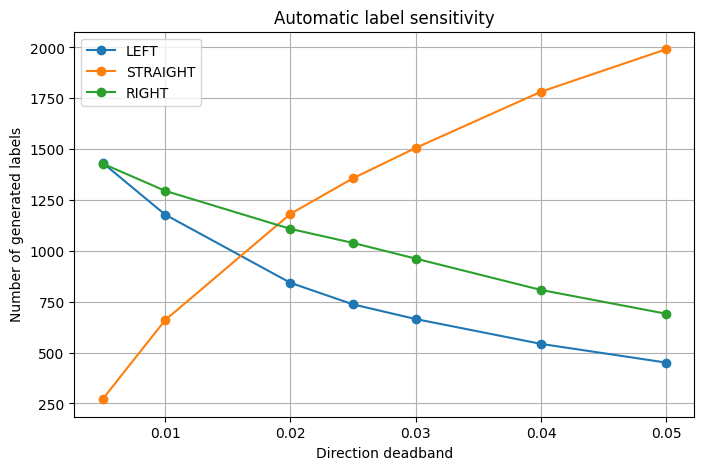

In [38]:
def evaluate_deadband_sensitivity(labelled, deadbands):
    rows = []

    for deadband in deadbands:
        temp = labelled.copy()
        temp["label_recomputed"] = np.where(
            temp["direction_score"] < -deadband,
            "LEFT",
            np.where(temp["direction_score"] > deadband, "RIGHT", "STRAIGHT"),
        )
        counts = temp["label_recomputed"].value_counts().reindex(CLASS_NAMES, fill_value=0)
        rows.append({
            "deadband": deadband,
            "LEFT": counts["LEFT"],
            "STRAIGHT": counts["STRAIGHT"],
            "RIGHT": counts["RIGHT"],
        })

    return pd.DataFrame(rows)

sensitivity_df = evaluate_deadband_sensitivity(
    labelled_df,
    deadbands=[0.005, 0.010, 0.020, 0.025, 0.030, 0.040, 0.050],
)

display(sensitivity_df)

plt.figure(figsize=(8, 5))
for label in CLASS_NAMES:
    plt.plot(sensitivity_df["deadband"], sensitivity_df[label], marker="o", label=label)
plt.xlabel("Direction deadband")
plt.ylabel("Number of generated labels")
plt.title("Automatic label sensitivity")
plt.legend()
plt.grid(True)
plt.show()

## 14. Optional: Save the Trained Model

In [39]:
SAVE_MODEL = True
MODEL_OUTPUT = ROOT / "svm_green_line_model.joblib"

if SAVE_MODEL:
    import joblib

    payload = {
        "model": best_model,
        "feature_columns": FEATURE_COLUMNS,
        "class_names": CLASS_NAMES.tolist(),
        "hsv_lower": HSV_LOWER.tolist(),
        "hsv_upper": HSV_UPPER.tolist(),
        "roi_start_fraction": ROI_START_FRACTION,
        "direction_deadband": DIRECTION_DEADBAND,
    }
    joblib.dump(payload, MODEL_OUTPUT)
    print("Saved model:", MODEL_OUTPUT)
else:
    print("Model saving disabled. Set SAVE_MODEL = True to write the trained model file.")

Model saving disabled. Set SAVE_MODEL = True to write the trained model file.
